<a href="https://colab.research.google.com/github/muhammadrafique92/Assignment/blob/main/Assignment_6_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

In [1]:

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1608s 9us/step


In [4]:
print("Training data:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing data:", x_test.shape)
print("Testing labels:", y_test.shape)


Training data: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing data: (10000, 32, 32, 3)
Testing labels: (10000, 1)


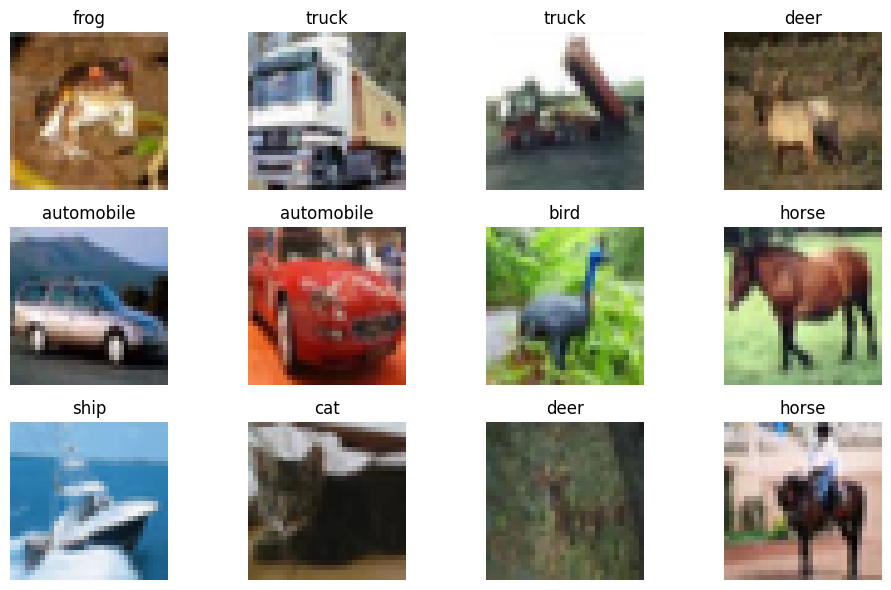

In [5]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [7]:
print(x_train.min())
print(x_train.max())

0.0
1.0


In [8]:
model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 83ms/step - accuracy: 0.4164 - loss: 1.5915 - val_accuracy: 0.5198 - val_loss: 1.3361
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.5621 - loss: 1.2357 - val_accuracy: 0.5938 - val_loss: 1.1407
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.6208 - loss: 1.0734 - val_accuracy: 0.6142 - val_loss: 1.1111
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 81ms/step - accuracy: 0.6553 - loss: 0.9738 - val_accuracy: 0.6696 - val_loss: 0.9602
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 80ms/step - accuracy: 0.6881 - loss: 0.8937 - val_accuracy: 0.6884 - val_loss: 0.9022
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.7047 - loss: 0.8377 - val_accuracy: 0.6998 - val_loss: 0.8817
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.7232 - loss: 0.7895 - val_accuracy: 0.7038 - val_loss: 0.8542
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.7415 - loss: 0.7413 - 

In [12]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=2
)

print("Test accuracy:", test_accuracy)

313/313 - 4s - 12ms/step - accuracy: 0.7033 - loss: 0.8816
Test accuracy: 0.7032999992370605


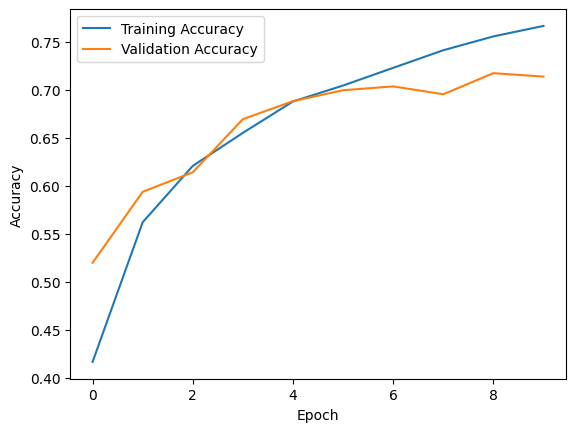

In [13]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

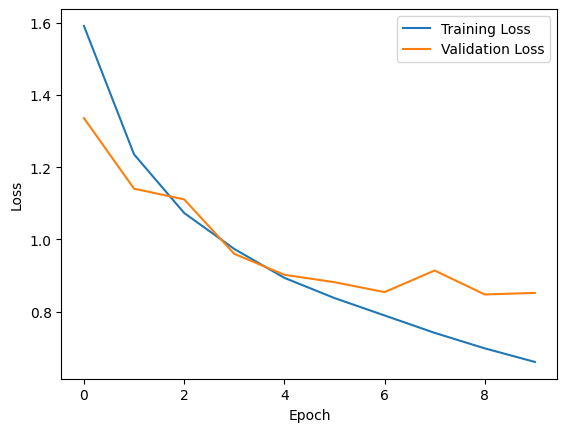

In [14]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [17]:
predicted_class = np.argmax(predictions[0])
actual_class = y_test[0][0]

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[actual_class])

Predicted: cat
Actual: cat


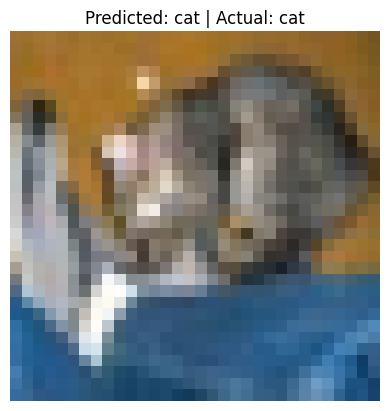

In [18]:
plt.imshow(x_test[0])
plt.title(
    f"Predicted: {class_names[predicted_class]} | "
    f"Actual: {class_names[actual_class]}"
)
plt.axis('off')
plt.show()